# Language Detection

The goal is to identify the language of a text. The dataset has 22 languages with 1,000 sentences each, taken from Wikipedia (`dataset.csv`).

Reference solution: [Language Detection with Machine Learning](https://amanxai.com/2021/10/30/language-detection-with-machine-learning/) (Aman Kharwal). Dataset: [dataset.csv](https://raw.githubusercontent.com/amankharwal/Website-data/master/dataset.csv).

The reference turns the sentences into word counts (`CountVectorizer`), trains a Multinomial Naive Bayes on a 67/33 split and reports one accuracy. Several points are checked here: the duplicated sentences, languages that are not written with spaces between words (Chinese, Japanese), a comparison with the `langdetect` library, and the question a reader asked in the comments, what happens with a language that is not in the data.

In [1]:
#pip install langdetect

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from langdetect import detect, DetectorFactory

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/NLP/language_detection')

## Data Loading

In [3]:
data = pd.read_csv("dataset.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Text      22000 non-null  str  
 1   language  22000 non-null  str  
dtypes: str(2)
memory usage: 12.6 MB


In [4]:
data["language"].value_counts().head(3)

language
Estonian    1000
Swedish     1000
Thai        1000
Name: count, dtype: int64

## Data Cleaning

There are no null values and every language has 1,000 sentences. Two problems remain: 141 rows are exact duplicates (the same sentence appears twice), and the label "Portugese" is misspelled. Duplicates matter for the evaluation: with a random split, the same sentence can be in the training and in the test set, and the model is then tested on a sentence it has already seen.

In [5]:
print("duplicated rows:", data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
data["language"] = data["language"].replace({"Portugese": "Portuguese"})
data["language"].value_counts().describe()[["min", "max"]]

duplicated rows: 141


min     953.0
max    1000.0
Name: count, dtype: float64

## Exploratory Data Analysis

In [6]:
data["words"] = data["Text"].str.split().str.len()
data["characters"] = data["Text"].str.len()

data.groupby("language")[["words", "characters"]].median().sort_values("words").T.round(0)

language,Chinese,Japanese,Thai,Estonian,Tamil,Latin,Turkish,Romanian,Dutch,Russian,...,Urdu,French,Portuguese,Spanish,Korean,Arabic,English,Persian,Pushto,Hindi
words,1.0,1.0,14.0,30.0,33.0,33.0,39.0,40.0,41.0,41.0,...,49.0,51.0,52.0,53.0,55.0,56.0,56.0,58.0,67.0,71.0
characters,200.0,192.0,303.0,239.0,295.0,236.0,300.0,253.0,262.0,299.0,...,246.0,314.0,306.0,314.0,232.0,332.0,336.0,304.0,319.0,378.0


Chinese and Japanese are written without spaces between words, so a sentence has a median of one "word" when the text is split on spaces (Thai has 14, against 30 to 70 for the other languages). A word-count model (`CountVectorizer` splits on word boundaries made of letters and digits) cannot see the inside of a Chinese or Japanese sentence: the whole sentence is one token, or a few.

## Reference Reproduction

The reference is reproduced on the original data (duplicates included), with word counts, Multinomial Naive Bayes and its split (33% test, `random_state=42`). The recall of every language is shown, together with the share of test sentences that also appear in the training set.

In [7]:
raw = pd.read_csv("dataset.csv")
raw_x = CountVectorizer().fit_transform(raw["Text"])
raw_train, raw_test, raw_y_train, raw_y_test = train_test_split(raw_x, raw["language"], test_size=0.33, random_state=42)
raw_pred = MultinomialNB().fit(raw_train, raw_y_train).predict(raw_test)

raw_text_train, raw_text_test = train_test_split(raw["Text"], test_size=0.33, random_state=42)
print("reference accuracy:", round(accuracy_score(raw_y_test, raw_pred), 4))
print("share of test sentences also present in the training set:", round(raw_text_test.isin(raw_text_train).mean(), 4))

report = pd.DataFrame(classification_report(raw_y_test, raw_pred, output_dict=True)).T
report.loc[report.index.difference(["accuracy", "macro avg", "weighted avg"]), ["recall", "f1-score"]].sort_values("recall").head(5).round(3)

reference accuracy: 0.9532
share of test sentences also present in the training set: 0.0087


,recall,f1-score
Chinese,0.502,0.652
Japanese,0.866,0.770
Latin,0.908,0.947
Portugese,0.956,0.977
Estonian,0.962,0.975


## Feature Engineering

The cleaned data is split 80/20 and stratified, so that every language keeps the same share in both sets, and no sentence is in both sets. Two ways to turn text into numbers are compared. Word counts, as in the reference, and counts of character sequences of one to three characters (`CountVectorizer(analyzer="char", ngram_range=(1, 3))`). Character sequences work in every writing system, because they do not need word boundaries, and they also capture the typical letter combinations of a language.

In [8]:
x_train, x_test, y_train, y_test = train_test_split(data["Text"], data["language"], test_size=0.2, random_state=42, stratify=data["language"])

word_vectorizer = CountVectorizer().fit(x_train)
char_vectorizer = CountVectorizer(analyzer="char", ngram_range=(1, 3)).fit(x_train)
print("word features:", len(word_vectorizer.vocabulary_), "| character features:", len(char_vectorizer.vocabulary_))

word features: 237644 | character features: 566203


## Model Training

Three models are trained on the training set: Multinomial Naive Bayes on word counts (the reference), Multinomial Naive Bayes on character counts, and Logistic Regression on character counts. The `langdetect` library is added as an external reference: it needs no training, but it does not know Latin and Pushto, so the sentences of those languages can never be right.

In [9]:
naive_words = MultinomialNB().fit(word_vectorizer.transform(x_train), y_train)
naive_chars = MultinomialNB().fit(char_vectorizer.transform(x_train), y_train)
logistic_chars = LogisticRegression(max_iter=300).fit(char_vectorizer.transform(x_train), y_train)

DetectorFactory.seed = 0
codes = {"ar": "Arabic", "zh-cn": "Chinese", "zh-tw": "Chinese", "nl": "Dutch", "en": "English", "et": "Estonian", "fr": "French",
         "hi": "Hindi", "id": "Indonesian", "ja": "Japanese", "ko": "Korean", "fa": "Persian", "pt": "Portuguese", "ro": "Romanian",
         "ru": "Russian", "es": "Spanish", "sv": "Swedish", "ta": "Tamil", "th": "Thai", "tr": "Turkish", "ur": "Urdu"}

def safe_detect(text):
    try:
        return codes.get(detect(text), "other")
    except Exception:
        return "other"

predictions = {
    "Naive Bayes, words (reference)": naive_words.predict(word_vectorizer.transform(x_test)),
    "Naive Bayes, characters": naive_chars.predict(char_vectorizer.transform(x_test)),
    "Logistic Regression, characters": logistic_chars.predict(char_vectorizer.transform(x_test)),
    "langdetect library": x_test.map(safe_detect).values,
}

## Evaluation

In [10]:
pd.DataFrame({name: {"Accuracy": accuracy_score(y_test, p), "Macro F1": f1_score(y_test, p, average="macro")}
              for name, p in predictions.items()}).T.round(4)

,Accuracy,Macro F1
"Naive Bayes, words (reference)",0.9559,0.9567
"Naive Bayes, characters",0.9767,0.9779
"Logistic Regression, characters",0.9844,0.9846
langdetect library,0.8774,0.8182


In [11]:
recall_by_language = pd.DataFrame({name: pd.Series(classification_report(y_test, p, output_dict=True, zero_division=0)).drop(["accuracy", "macro avg", "weighted avg"]).map(lambda r: r["recall"])
                                   for name, p in predictions.items()})
recall_by_language.sort_values("Naive Bayes, words (reference)").head(8).round(3)

,"Naive Bayes, words (reference)","Naive Bayes, characters","Logistic Regression, characters",langdetect library
Japanese,0.620,0.985,1.000,0.990
Chinese,0.855,0.990,0.985,0.710
Latin,0.911,0.895,0.969,0.000
Pushto,0.935,0.925,0.935,0.000
Portuguese,0.955,0.955,0.985,0.950
Hindi,0.965,0.965,0.970,0.965
Estonian,0.970,0.960,0.985,0.950
Urdu,0.975,0.975,0.975,0.890


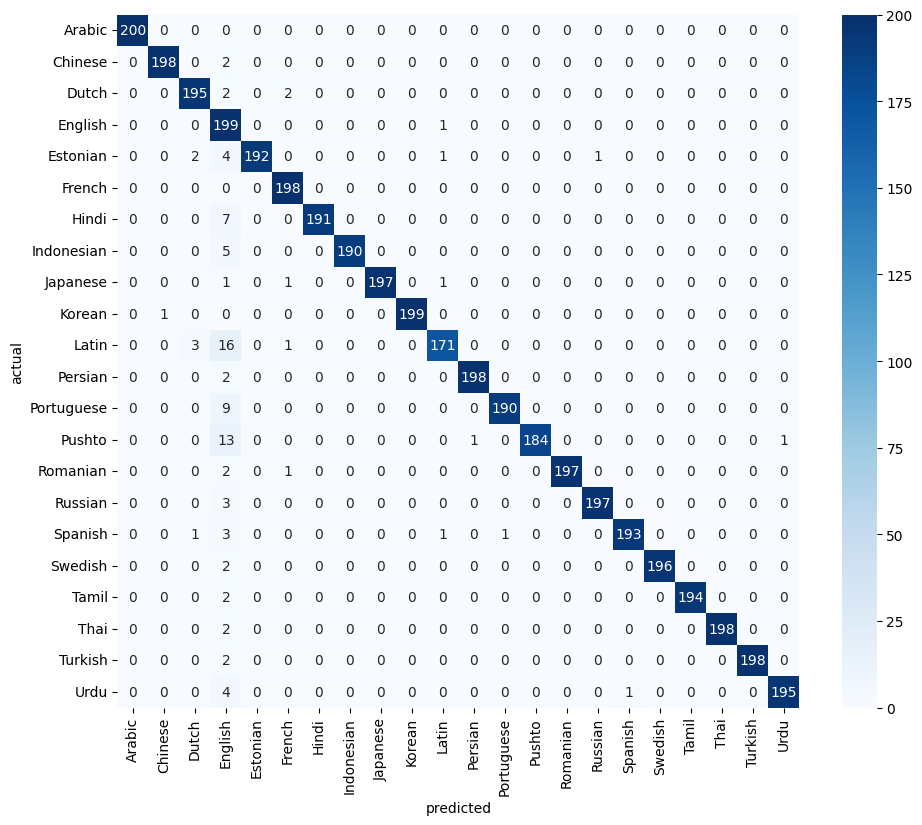

,row_0,col_0,count
25,Latin,English,16
32,Pushto,English,13
30,Portuguese,English,9
14,Hindi,English,7
16,Indonesian,English,5
54,Urdu,English,4


In [12]:
best = predictions["Naive Bayes, characters"]
languages = sorted(y_test.unique())

plt.figure(figsize=(11, 9))
sns.heatmap(confusion_matrix(y_test, best, labels=languages), annot=True, fmt="d", cmap="Blues", xticklabels=languages, yticklabels=languages)
plt.xlabel("predicted"); plt.ylabel("actual"); plt.show()

errors = pd.crosstab(y_test.values, best)
confused = errors.stack()[lambda s: s > 0].rename("count").reset_index()
confused[confused.iloc[:, 0] != confused.iloc[:, 1]].sort_values("count", ascending=False).head(6)

## A Language That Is Not in the Data

A reader of the reference asked what happens when the text is in a language the model does not know. The model always answers with one of its 22 languages. The maximum predicted probability could be used as a confidence and a low value as a sign of an unknown language. It is tested on the same sentence in three known and five unknown languages (German, Italian, Greek, Bengali, Polish).

In [13]:
sentences = {
    "English (known)": "The weather is very nice today and we are going for a walk in the park.",
    "Spanish (known)": "Hoy hace muy buen tiempo y vamos a dar un paseo por el parque.",
    "Turkish (known)": "Bugun hava cok guzel ve parkta yuruyus yapmaya gidiyoruz.",
    "German (unknown)": "Das Wetter ist heute sehr schoen und wir gehen im Park spazieren.",
    "Italian (unknown)": "Oggi il tempo e bellissimo e andiamo a fare una passeggiata nel parco.",
    "Greek (unknown)": "Ο καιρός σήμερα είναι πολύ ωραίος και πηγαίνουμε βόλτα στο πάρκο.",
    "Bengali (unknown)": "আজ আবহাওয়া খুব সুন্দর এবং আমরা পার্কে হাঁটতে যাচ্ছি।",
    "Polish (unknown)": "Dzisiaj pogoda jest bardzo ladna i idziemy na spacer do parku.",
}
features = char_vectorizer.transform(list(sentences.values()))

pd.DataFrame({
    "Naive Bayes: prediction": naive_chars.predict(features), "Naive Bayes: confidence": naive_chars.predict_proba(features).max(axis=1).round(3),
    "Logistic Regression: prediction": logistic_chars.predict(features), "Logistic Regression: confidence": logistic_chars.predict_proba(features).max(axis=1).round(3),
}, index=list(sentences))

,Naive Bayes: prediction,Naive Bayes: confidence,Logistic Regression: prediction,Logistic Regression: confidence
English (known),English,1.000,English,0.895
Spanish (known),Spanish,1.000,Spanish,0.857
Turkish (known),Turkish,1.000,Turkish,0.424
German (unknown),Dutch,1.000,Dutch,0.291
Italian (unknown),Portuguese,1.000,Spanish,0.310
Greek (unknown),Latin,1.000,Korean,0.466
Bengali (unknown),Urdu,0.900,Korean,0.352
Polish (unknown),Spanish,0.994,Spanish,0.273


In [14]:
confidence = pd.DataFrame({"Naive Bayes": naive_chars.predict_proba(char_vectorizer.transform(x_test)).max(axis=1),
                           "Logistic Regression": logistic_chars.predict_proba(char_vectorizer.transform(x_test)).max(axis=1)})
confidence.describe().loc[["min", "25%", "50%"]].round(3)

,Naive Bayes,Logistic Regression
min,0.5,0.116
25%,1.0,1.000
50%,1.0,1.000


The reference Naive Bayes on word counts reaches an accuracy of 0.953 with its original split. On the cleaned split it reaches 0.956, and only 0.87% of its test sentences were also in its training set, so the duplicates inflate the score very little. The real weakness is visible per language: Japanese (recall 0.62) and Chinese (0.855) are recognised much worse than the other languages, because a sentence written without spaces is one single token for a word counter and can only be recognised if that exact token was seen in training. Counting sequences of one to three characters removes the problem (Japanese 0.985, Chinese 0.990) and raises the accuracy to 0.977 with the same Naive Bayes, and to 0.984 with Logistic Regression.

The `langdetect` library reaches only 0.877. It does not know Latin and Pushto (recall 0 for both), and it separates Chinese from the other languages less well (0.71). On the 20 languages it supports it is competitive, but it cannot serve as a reference for a dataset that contains languages it was not built for.

The remaining errors of the best models are mostly predictions of "English" for sentences of another language (Latin, Pushto, Portuguese, Hindi, Indonesian, Estonian): Wikipedia sentences often contain English names and terms, so a few of them are mostly English words.

For a language that is not in the data, Naive Bayes is not usable as a detector: it answers with a confidence of 1.0 for German (Dutch), Italian (Portuguese) and Greek (Latin). Logistic Regression gives a lower confidence for the unknown languages (0.26 to 0.37) than for the clear known sentences (0.80 and 0.91 for English and Spanish), but the difference is not large enough to draw a clean line: the known Turkish sentence has a confidence of 0.43. The sentences of this test were written without diacritics, which makes them harder. A rejection threshold on the Logistic Regression confidence would catch many unknown languages but also some short known sentences.

## Conclusion

**Reference approach.** The reference counts words (`CountVectorizer`), trains a Multinomial Naive Bayes on a 67/33 random split and reports one accuracy. It does not remove the 141 duplicated sentences, does not look at the languages one by one, and does not discuss the question of one of its readers about texts in a language that is not in the data.

**Findings.** Reproducing it gave an accuracy of 0.953. The duplicates have a negligible effect (0.87% of the test sentences were also in training), but the score per language shows that Chinese (recall 0.50 in the original split) and Japanese (0.62 on the cleaned split) are badly handled: they are written without spaces, so a word counter sees one token per sentence.

**Our models** (cleaned data, 80/20 stratified split, 4,372 test sentences):

| Model | Accuracy | Macro F1 |
|---|---|---|
| Naive Bayes, words (reference) | 0.956 | 0.957 |
| Naive Bayes, character sequences (1 to 3) | 0.977 | 0.978 |
| Logistic Regression, character sequences | 0.984 | 0.984 |
| `langdetect` library | 0.877 | 0.818 |

Character sequences work in every writing system and lift the recall of Japanese and Chinese from 0.62 and 0.86 to 0.985 and 0.99. The `langdetect` library does not know Latin and Pushto, and has a lower score on this data.

**Unknown languages.** Naive Bayes always answers with a very high confidence, even for German, Italian, Greek, Bengali and Polish, which are not in the data. Logistic Regression is less sure for them (0.26 to 0.37), which helps only partly. A model that must say "unknown language" needs either an "other" class trained with examples of other languages or a confidence threshold that is tuned on such examples.

**Limitations.** The sentences come from Wikipedia and are fairly long (about 300 characters); short messages such as chat texts or single words would be much harder. The data has only 22 languages. The unknown-language test used five hand-written sentences, so it only illustrates the behaviour and is not a measured rate.